# Simple Regression

The dataset consisted of the following columns:
- TV: Amount spent on TV advertising (Budget for TV Advertisements in 1000 dollers)
- Radio: Amount spent on radio advertising (Budget for Radio Advertisements in 1000 dollers)
- Newspaper: Amount spent on newspaper advertising (Budget for Newspaper Advertisements in 1000 dollers)
- Sales: Total sales generated (Sales Revenue in Million dollers)

## Understand the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
from pathlib import Path

dataset_dir = os.path.join(Path.cwd(), '..', 'datasets')

'/Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../datasets'

In [13]:
data = pd.read_csv(f"{dataset_dir}/TV_advertising.csv")
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [15]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [16]:
# any null values in the dataset?
print(data.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [17]:
# Statistical summary of the dataset
print(data.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [18]:
# duplicate rows in the dataset?
print(data.duplicated().sum())

0


## Visualize the Data

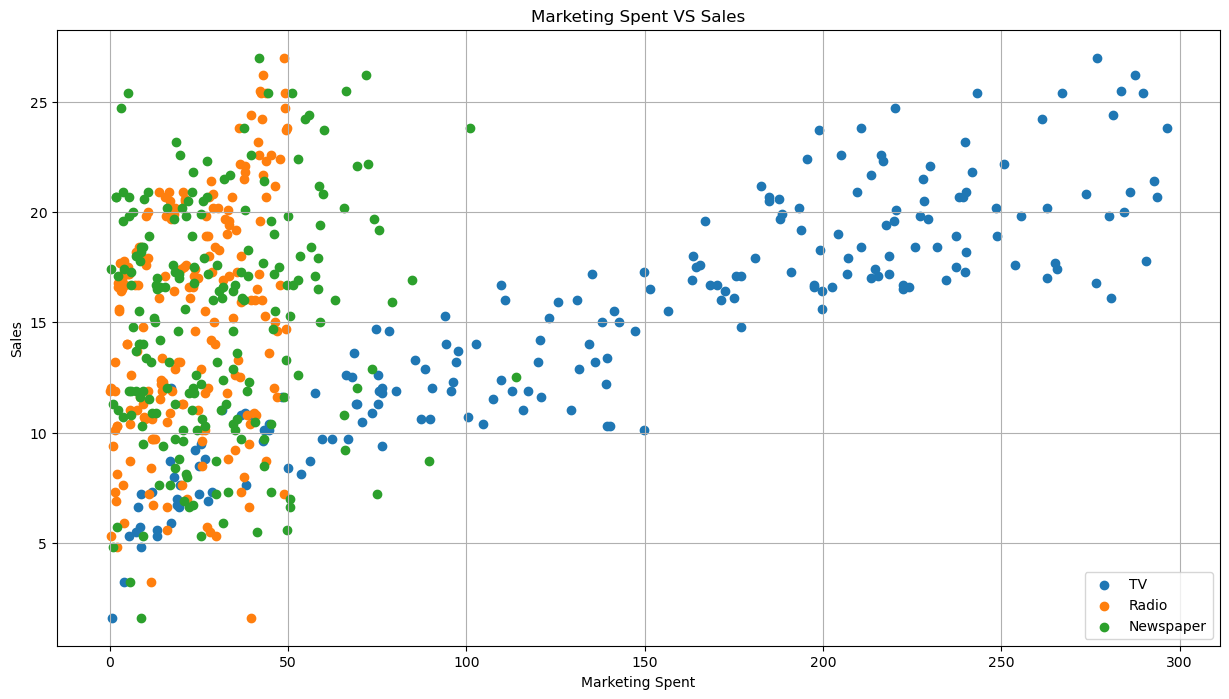

In [19]:
# Visualize the data

plt.figure(figsize=[15,8])
plt.scatter(x = data['TV'], y = data['Sales'], label = 'TV')
plt.scatter(x = data['Radio'], y = data['Sales'], label = 'Radio')
plt.scatter(x = data['Newspaper'], y = data['Sales'], label = 'Newspaper')
plt.title('Marketing Spent VS Sales')
plt.xlabel('Marketing Spent')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

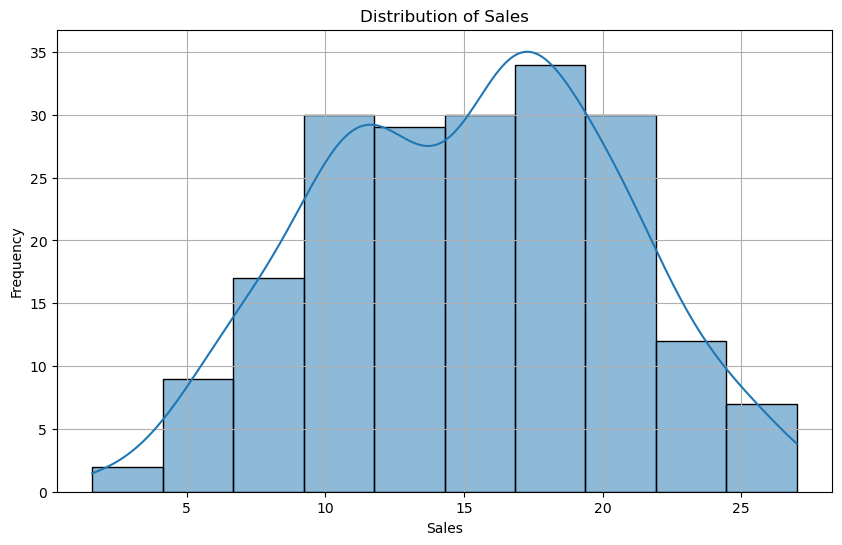

In [20]:
# distribution of the target variable
plt.figure(figsize=[10,6])
sns.histplot(data['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

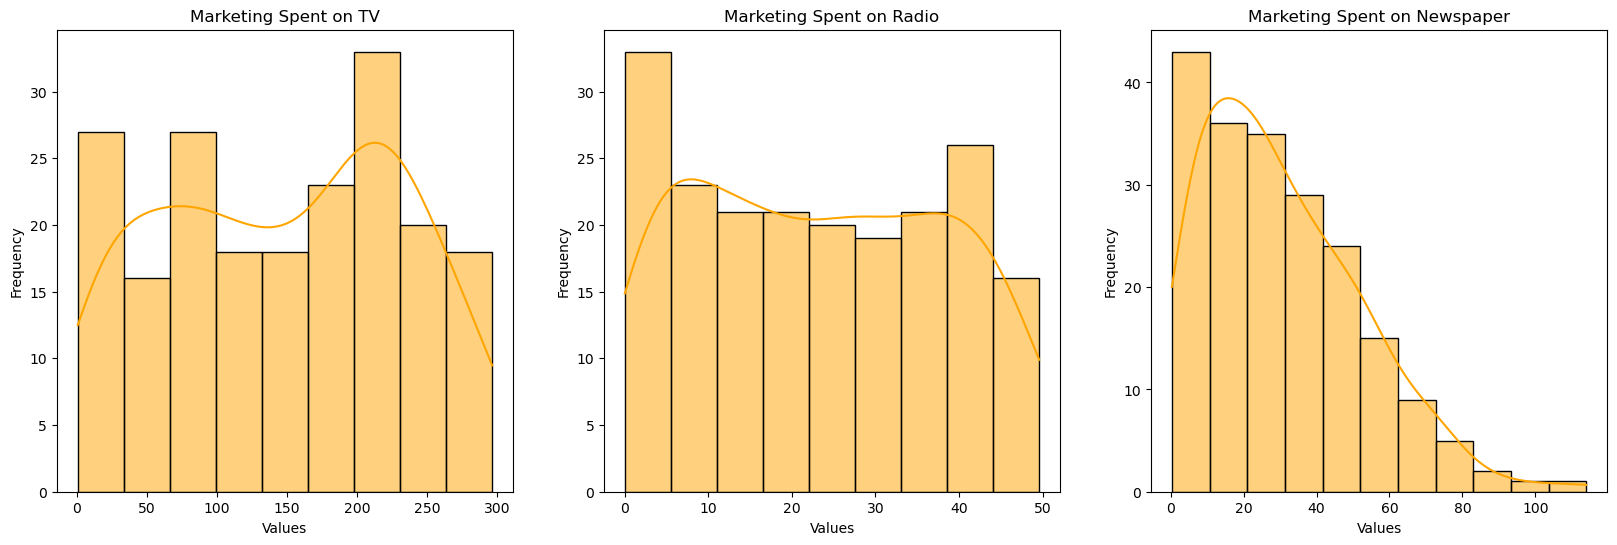

In [23]:
# distribution of the target variable

plt.figure(figsize=[20,6])
for i, column in enumerate(data[['TV','Radio','Newspaper']], 1):
    plt.subplot(1, 3, i)
    sns.histplot(data[column], color = 'orange', kde=True)
    plt.title(f'Marketing Spent on {column}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')

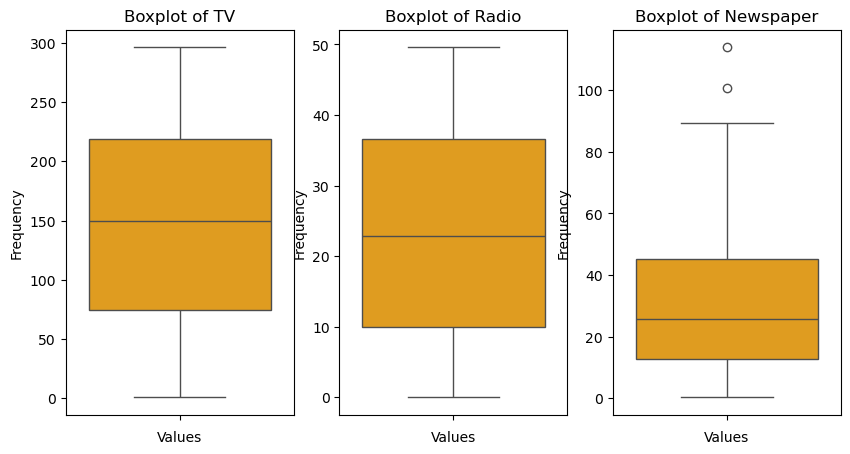

In [25]:
# boxplot to identify outliers
plt.figure(figsize=[10,5])
for i, column in enumerate(data[['TV','Radio','Newspaper']], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data[column], color = 'orange')
    plt.title(f'Boxplot of {column}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')

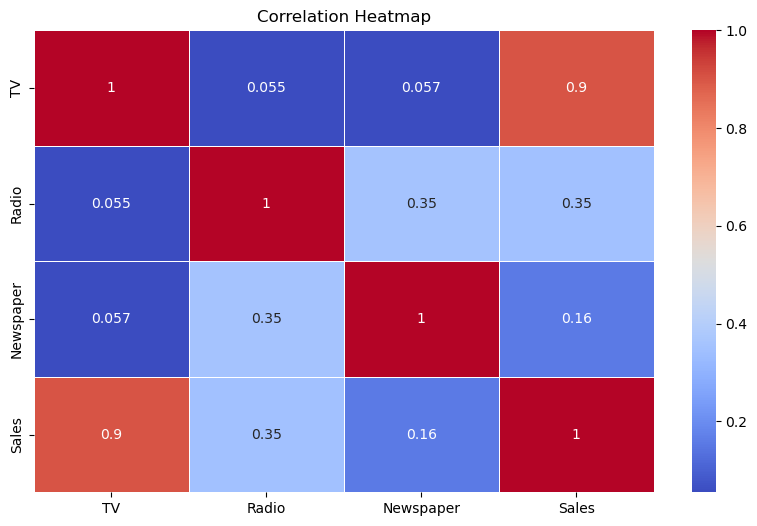

In [27]:
# any correlation between the features and the target variable?
plt.figure(figsize=[10,6])
sns.heatmap(data.corr(method='pearson'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Build the model

The data looks like a pattern of a linear regression

In [35]:
# define features and target variable
X = data['TV'].values.reshape(-1, 1)  # TV advertising spend as the feature
y = data['Sales']

In [36]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [42]:
# Coefficients of the model
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Slope: 0.0555
Intercept: 7.0071


## What is the Model then?

`Y = 0.0555.X + 7.0071

## Model Evaluation

In [45]:
# R-squared value
r2_train = r2_score(y_train, y_train_pred)
print(f"R-squared for {model.__class__.__name__} Train: {r2_train:.4f}")

r2_test = r2_score(y_test, y_test_pred)
print(f"R-squared for {model.__class__.__name__} Test: {r2_test:.4f}")

# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Train: {mse_train:.4f}")

mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Test: {mse_test:.4f}")

R-squared for LinearRegression Train: 0.8135
R-squared for LinearRegression Test: 0.8026
Mean Squared Error for LinearRegression Train: 4.9984
Mean Squared Error for LinearRegression Test: 6.1011


Text(0, 0.5, 'Sales')

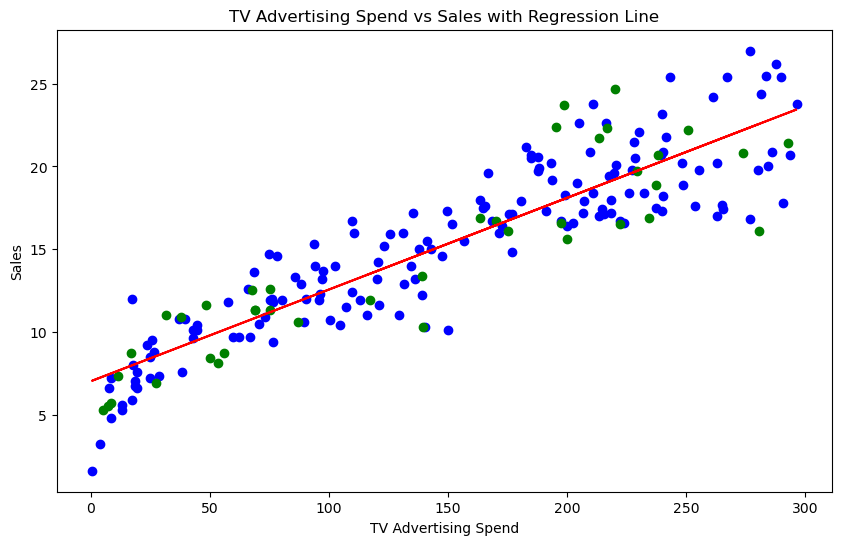

In [46]:
# Visualize the model's predictions
plt.figure(figsize=[10,6])
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Testing Data')
plt.plot(X_train, y_train_pred, color='red', label='Regression Line')
plt.title('TV Advertising Spend vs Sales with Regression Line')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')

## Error Analysis (Residual)

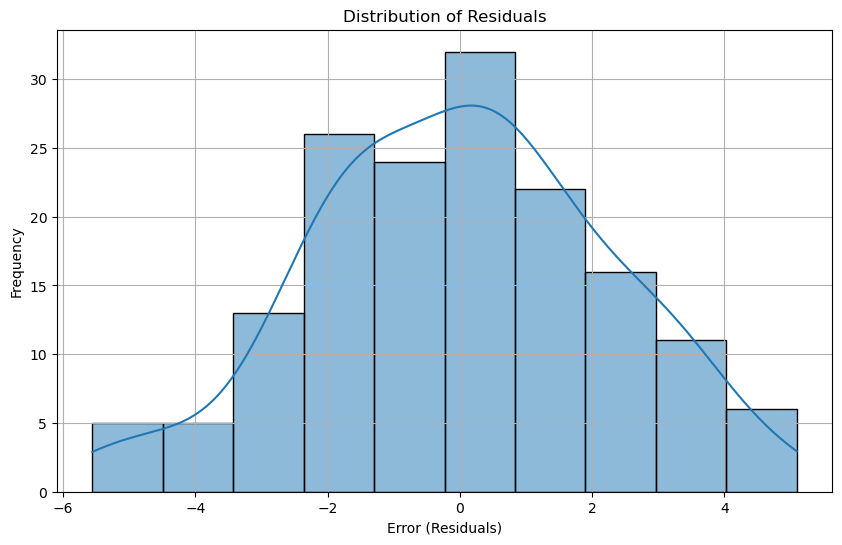

In [49]:
residuals = y_train - y_train_pred
plt.figure(figsize=[10,6])
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Error (Residuals)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()